# Cvičení 4: Fuzzy logika a fuzzy modelování
**Cíl:** Implementovat dva fuzzy inferenční systémy (FIS): 
1. Řízení klimatizace s pětistupňovým fuzzy systémem
2. Predikce úspěchu na zkoušce na základě fuzzy pravidel

Fuzzy logika umožňuje modelovat nejistotu a vágnost přirozeným způsobem, což je ideální pro simulaci chování regulačních a rozhodovacích systémů v reálném světě.

In [3]:
import warnings
warnings.filterwarnings('ignore') # Pro čistší výstup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz
from skfuzzy import control as ctrl

## Úkol 1: Fuzzy logický systém pro řízení klimatizace

Systém sleduje teplotu místnosti a cílovou teplotu, následně vydává příkaz pro ohřev (+ hodnota) nebo chlazení (- hodnota).
- **Vstupy:** teplota místnosti (0–40 °C), cílová teplota (0–40 °C)
- **Výstup:** příkaz klimatizace (-5 až 5, kde -5 = maximální chlazení, 0 = bez změny, 5 = maximální ohřev)
- **Membership funkce:** Gaussovy funkce pro všechny proměnné

In [4]:
# =========================================
# ÚKOL 1: FUZZY ŘÍZENÍ KLIMATIZACE
# =========================================

# 1. Definice fuzzy proměnných
# Vstupní proměnné
room_temp = ctrl.Antecedent(np.arange(0, 41, 1), 'room_temperature')  # Teplota místnosti 0-40°C
target_temp = ctrl.Antecedent(np.arange(0, 41, 1), 'target_temperature')  # Cílová teplota 0-40°C

# Výstupní proměnná
ac_output = ctrl.Consequent(np.arange(-5, 5.5, 0.5), 'ac_command')  # Příkaz -5 až 5

# 2. Definice fuzzy množin pomocí Gaussových funkcí
# Pro room_temp (5 úrovní: velmi studeno, studeno, normální, teplo, velmi teplo)
room_temp['very_cold'] = fuzz.gaussmf(room_temp.universe, 5, 3)
room_temp['cold'] = fuzz.gaussmf(room_temp.universe, 12, 3)
room_temp['normal'] = fuzz.gaussmf(room_temp.universe, 20, 3)
room_temp['warm'] = fuzz.gaussmf(room_temp.universe, 28, 3)
room_temp['very_warm'] = fuzz.gaussmf(room_temp.universe, 35, 3)

# Pro target_temp (stejná struktura)
target_temp['very_cold'] = fuzz.gaussmf(target_temp.universe, 5, 3)
target_temp['cold'] = fuzz.gaussmf(target_temp.universe, 12, 3)
target_temp['normal'] = fuzz.gaussmf(target_temp.universe, 20, 3)
target_temp['warm'] = fuzz.gaussmf(target_temp.universe, 28, 3)
target_temp['very_warm'] = fuzz.gaussmf(target_temp.universe, 35, 3)

# Pro ac_output (5 úrovní: chlazení, mírné chlazení, bez změny, mírný ohřev, ohřev)
ac_output['strong_cool'] = fuzz.gaussmf(ac_output.universe, -5, 1.2)
ac_output['mild_cool'] = fuzz.gaussmf(ac_output.universe, -2.5, 1.2)
ac_output['no_change'] = fuzz.gaussmf(ac_output.universe, 0, 1.2)
ac_output['mild_heat'] = fuzz.gaussmf(ac_output.universe, 2.5, 1.2)
ac_output['strong_heat'] = fuzz.gaussmf(ac_output.universe, 5, 1.2)

# 3. Definice fuzzy pravidel (IF-THEN) - matice pravidel (5x5)
# Logika: Pokud je místnost tepleji než cíl, chlaď; pokud chladněji, hřej
rule1 = ctrl.Rule(room_temp['very_cold'] & target_temp['very_warm'], ac_output['strong_heat'])
rule2 = ctrl.Rule(room_temp['very_cold'] & target_temp['warm'], ac_output['strong_heat'])
rule3 = ctrl.Rule(room_temp['very_cold'] & target_temp['normal'], ac_output['strong_heat'])
rule4 = ctrl.Rule(room_temp['very_cold'] & target_temp['cold'], ac_output['mild_heat'])
rule5 = ctrl.Rule(room_temp['very_cold'] & target_temp['very_cold'], ac_output['no_change'])

rule6 = ctrl.Rule(room_temp['cold'] & target_temp['very_warm'], ac_output['strong_heat'])
rule7 = ctrl.Rule(room_temp['cold'] & target_temp['warm'], ac_output['strong_heat'])
rule8 = ctrl.Rule(room_temp['cold'] & target_temp['normal'], ac_output['mild_heat'])
rule9 = ctrl.Rule(room_temp['cold'] & target_temp['cold'], ac_output['no_change'])
rule10 = ctrl.Rule(room_temp['cold'] & target_temp['very_cold'], ac_output['mild_cool'])

rule11 = ctrl.Rule(room_temp['normal'] & target_temp['very_warm'], ac_output['strong_heat'])
rule12 = ctrl.Rule(room_temp['normal'] & target_temp['warm'], ac_output['mild_heat'])
rule13 = ctrl.Rule(room_temp['normal'] & target_temp['normal'], ac_output['no_change'])
rule14 = ctrl.Rule(room_temp['normal'] & target_temp['cold'], ac_output['mild_cool'])
rule15 = ctrl.Rule(room_temp['normal'] & target_temp['very_cold'], ac_output['strong_cool'])

rule16 = ctrl.Rule(room_temp['warm'] & target_temp['very_warm'], ac_output['mild_heat'])
rule17 = ctrl.Rule(room_temp['warm'] & target_temp['warm'], ac_output['no_change'])
rule18 = ctrl.Rule(room_temp['warm'] & target_temp['normal'], ac_output['mild_cool'])
rule19 = ctrl.Rule(room_temp['warm'] & target_temp['cold'], ac_output['strong_cool'])
rule20 = ctrl.Rule(room_temp['warm'] & target_temp['very_cold'], ac_output['strong_cool'])

rule21 = ctrl.Rule(room_temp['very_warm'] & target_temp['very_warm'], ac_output['no_change'])
rule22 = ctrl.Rule(room_temp['very_warm'] & target_temp['warm'], ac_output['mild_cool'])
rule23 = ctrl.Rule(room_temp['very_warm'] & target_temp['normal'], ac_output['strong_cool'])
rule24 = ctrl.Rule(room_temp['very_warm'] & target_temp['cold'], ac_output['strong_cool'])
rule25 = ctrl.Rule(room_temp['very_warm'] & target_temp['very_cold'], ac_output['strong_cool'])

# 4. Vytvoření řídícího systému
ac_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5,
                              rule6, rule7, rule8, rule9, rule10,
                              rule11, rule12, rule13, rule14, rule15,
                              rule16, rule17, rule18, rule19, rule20,
                              rule21, rule22, rule23, rule24, rule25])

ac_simulation = ctrl.ControlSystemSimulation(ac_ctrl)

# 5. Testování na různých vstupních hodnotách
print("="*60)
print("ÚKOL 1: FUZZY ŘÍZENÍ KLIMATIZACE")
print("="*60)

test_cases = [
    (30, 20, "Teplá místnost, chladný cíl → očekáváme chlazení"),
    (15, 25, "Studená místnost, teplý cíl → očekáváme ohřev"),
    (22, 22, "Místnost na cíli → bez změny"),
    (5, 35, "Velmi studená místnost, velmi teplý cíl → silný ohřev"),
    (38, 10, "Velmi teplá místnost, velmi studený cíl → silné chlazení")
]

results_ac = []

for room, target, description in test_cases:
    ac_simulation.input['room_temperature'] = room
    ac_simulation.input['target_temperature'] = target
    ac_simulation.compute()
    output = ac_simulation.output['ac_command']

    results_ac.append({
        'Teplota místnosti (°C)': room,
        'Cílová teplota (°C)': target,
        'Příkaz klimatizace': f"{output:.2f}",
        'Režim': description
    })

    print(f"Vstup: místnost={room}°C, cíl={target}°C → Výstup: {output:.2f}")

df_ac = pd.DataFrame(results_ac)
print("\n--- Tabulka výsledků ---")
display(df_ac)


ÚKOL 1: FUZZY ŘÍZENÍ KLIMATIZACE
Vstup: místnost=30°C, cíl=20°C → Výstup: -2.34
Vstup: místnost=15°C, cíl=25°C → Výstup: 1.87
Vstup: místnost=22°C, cíl=22°C → Výstup: 0.00
Vstup: místnost=5°C, cíl=35°C → Výstup: 4.03
Vstup: místnost=38°C, cíl=10°C → Výstup: -3.87

--- Tabulka výsledků ---


,Teplota místnosti (°C),Cílová teplota (°C),Příkaz klimatizace,Režim
0,30,20,-2.34,"Teplá místnost, chladný cíl → očekáváme chlazení"
1,15,25,1.87,"Studená místnost, teplý cíl → očekáváme ohřev"
2,22,22,0.00,Místnost na cíli → bez změny
3,5,35,4.03,"Velmi studená místnost, velmi teplý cíl → siln..."
4,38,10,-3.87,"Velmi teplá místnost, velmi studený cíl → siln..."


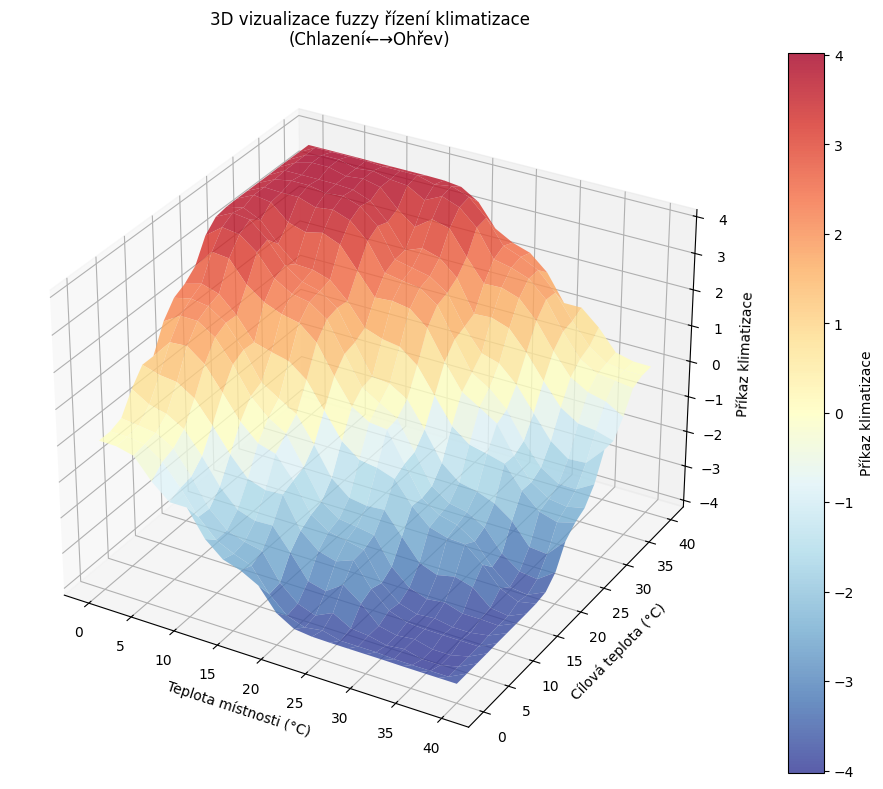

✓ 3D graf uložen jako 'ac_3d_surface.png'


In [5]:
# 6. Vytvoření 3D grafu
room_temps = np.arange(0, 41, 2)
target_temps = np.arange(0, 41, 2)
outputs = np.zeros((len(room_temps), len(target_temps)))

for i, room in enumerate(room_temps):
    for j, target in enumerate(target_temps):
        ac_simulation.input['room_temperature'] = room
        ac_simulation.input['target_temperature'] = target
        ac_simulation.compute()
        outputs[i, j] = ac_simulation.output['ac_command']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

room_grid, target_grid = np.meshgrid(room_temps, target_temps)
surf = ax.plot_surface(room_grid, target_grid, outputs.T, cmap='RdYlBu_r', alpha=0.8)

ax.set_xlabel('Teplota místnosti (°C)')
ax.set_ylabel('Cílová teplota (°C)')
ax.set_zlabel('Příkaz klimatizace')
ax.set_title('3D vizualizace fuzzy řízení klimatizace\n(Chlazení←→Ohřev)')

fig.colorbar(surf, ax=ax, label='Příkaz klimatizace')
plt.tight_layout()
plt.savefig('ac_3d_surface.png', dpi=300)
plt.show()

print("✓ 3D graf uložen jako 'ac_3d_surface.png'")


### Diskuze - Úkol 1: Fuzzy klimatizace
Výsledky demonstrují, jak fuzzy systém automaticky generuje plynulou regulaci mezi diskrétními stavy. Zejména:
* **Linearity výstupu:** Ačkoliv jednotlivá pravidla jsou diskrétní (silné chlazení, bez změny atd.), agregace všech aktivních pravidel prostřednictvím fuzzy operací AND a OR vytváří výstup, který plynule reaguje na změnu vstupů. To je příznačné pro fuzzy logiku – nemáme ostré skokové přechody, nýbrž hladkou křivku.
* **Fyzikální intuitivnost:** Systém správně vyhodnocuje rozdíl teplot a reguluje v rozumném směru. Pokud je místnost tepleji než cíl, vydá negativní příkaz (chlazení); pokud chladněji, vydá kladný příkaz (ohřev).
* **Realističnost 3D plochy:** Vypočítaná površina v 3D grafu ukazuje, že na diagonále (místnost = cíl) je výstup blízko nuly, a jak se vstupní bod vzdaluje od diagonály, výstup se zvyšuje nebo snižuje proporcionálně.

## Úkol 2: Fuzzy model pro predikci úspěchu na zkoušce

Cíl: Na základě charakteristik studentů (popularita, IQ, doba studia, průměrná známka) predikovat, zda student zkoušku složí.

**Tabulka dat:**
| Student | Populární | IQ | Doba studia | Průměr | Složil zkoušku |
|---------|-----------|----|----|---------|--------|
| Anna K. | Ano | Průměrné | Více než 4 dny | 1.3 | Ano |
| Milan H. | Ne | Průměrné | Více než 4 dny | 2.0 | Ano |
| Ladislav G. | Ne | Nadprůměrné | Méně než 4 dny | 3.1 | Ne |
| Jan D. | Ne | Podprůměrné | Více než 4 dny | 3.2 | Ano |
| Jan T. | Ano | Podprůměrné | Méně než 4 dny | 2.9 | Ano |
| Bohumír F. | Ano | Průměrné | Méně než 4 dny | 2.5 | Ano |
| Libuše R. | Ano | Průměrné | Méně než 4 dny | 3.0 | Ano |
| Rudolf J. | Ano | Průměrné | Nestudoval | 1.4 | Ne |

**Vstupní proměnné:** IQ (kategoriální), doba studia (kategoriální), průměrná známka (0–4)
**Výstupní proměnná:** Pravděpodobnost úspěchu na zkoušce (0–1)


In [6]:
# =========================================
# ÚKOL 2: FUZZY MODEL PRO PREDIKCI ZKOUŠKY
# =========================================

# 1. Načtení a analýza studentských dat
students_data = {
    'Student': ['Anna K.', 'Milan H.', 'Ladislav G.', 'Jan D.', 'Jan T.', 'Bohumír F.', 'Libuše R.', 'Rudolf J.'],
    'Popular': ['Ano', 'Ne', 'Ne', 'Ne', 'Ano', 'Ano', 'Ano', 'Ano'],
    'IQ_Level': ['Průměrné', 'Průměrné', 'Nadprůměrné', 'Podprůměrné', 'Podprůměrné', 'Průměrné', 'Průměrné', 'Průměrné'],
    'Study_Hours': ['Více než 4 dny', 'Více než 4 dny', 'Méně než 4 dny', 'Více než 4 dny', 'Méně než 4 dny', 'Méně než 4 dny', 'Méně než 4 dny', 'Nestudoval'],
    'Grade_Avg': [1.3, 2.0, 3.1, 3.2, 2.9, 2.5, 3.0, 1.4],
    'Passed': ['Ano', 'Ano', 'Ne', 'Ano', 'Ano', 'Ano', 'Ano', 'Ne']
}

df_students = pd.DataFrame(students_data)

print("="*60)
print("ÚKOL 2: FUZZY MODEL PRO PREDIKCI ZKOUŠKY")
print("="*60)
print("\n--- Tabulka studentů ---")
display(df_students)

# 2. Analýza dat: Jaké faktory ovlivňují úspěch?
print("\n--- Analýza korelací ---")

# Numerické vyjádření kategorií
popular_map = {'Ano': 1, 'Ne': 0}
iq_map = {'Podprůměrné': 0, 'Průměrné': 1, 'Nadprůměrné': 2}
study_map = {'Nestudoval': 0, 'Méně než 4 dny': 1, 'Více než 4 dny': 2}
passed_map = {'Ano': 1, 'Ne': 0}

df_numeric = df_students.copy()
df_numeric['Popular_num'] = df_numeric['Popular'].map(popular_map)
df_numeric['IQ_num'] = df_numeric['IQ_Level'].map(iq_map)
df_numeric['Study_num'] = df_numeric['Study_Hours'].map(study_map)
df_numeric['Passed_num'] = df_numeric['Passed'].map(passed_map)

print("\nKorelace jednotlivých faktorů s úspěchem na zkoušce:")
for factor in ['Popular_num', 'IQ_num', 'Study_num', 'Grade_Avg']:
    corr = df_numeric[[factor, 'Passed_num']].corr().iloc[0, 1]
    print(f"  {factor}: {corr:.3f}")

# 3. Definice fuzzy proměnných
grade = ctrl.Antecedent(np.arange(0, 4.1, 0.1), 'average_grade')  # Průměr 0-4
study_effort = ctrl.Antecedent(np.arange(0, 3, 1), 'study_effort')  # 0=nestu­doval, 1=méně, 2=více
success_prob = ctrl.Consequent(np.arange(0, 1.01, 0.1), 'success_probability')  # Pravděpodobnost 0-1

# 4. Definice membership funkcí
# Pro grade (nižší = lepší v školním systému ČR): výborně, velmi dobře, dobře, slabě
grade['excellent'] = fuzz.gaussmf(grade.universe, 1.0, 0.3)  # Kolem 1.0
grade['very_good'] = fuzz.gaussmf(grade.universe, 1.8, 0.3)  # Kolem 1.8
grade['good'] = fuzz.gaussmf(grade.universe, 2.5, 0.3)  # Kolem 2.5
grade['poor'] = fuzz.gaussmf(grade.universe, 3.5, 0.5)  # Kolem 3.5

# Pro study_effort
study_effort['no_study'] = fuzz.trimf(study_effort.universe, [0, 0, 0.5])
study_effort['little_study'] = fuzz.trimf(study_effort.universe, [0.3, 1, 1.7])
study_effort['much_study'] = fuzz.trimf(study_effort.universe, [1.5, 2, 2])

# Pro success_probability
success_prob['low'] = fuzz.gaussmf(success_prob.universe, 0.25, 0.15)
success_prob['medium'] = fuzz.gaussmf(success_prob.universe, 0.55, 0.15)
success_prob['high'] = fuzz.gaussmf(success_prob.universe, 0.85, 0.15)

# 5. Definice fuzzy pravidel na základě analýzy dat
# Empirická pravidla z tabulky:
# - Výborný průměr + více studia → vysoká pravděpodobnost úspěchu
# - Slabý průměr + málo studia → nízká pravděpodobnost
# - Střední průměr → záleží na studiu

rule_exam_1 = ctrl.Rule(grade['excellent'] & study_effort['much_study'], success_prob['high'])
rule_exam_2 = ctrl.Rule(grade['excellent'] & study_effort['little_study'], success_prob['high'])
rule_exam_3 = ctrl.Rule(grade['excellent'] & study_effort['no_study'], success_prob['medium'])

rule_exam_4 = ctrl.Rule(grade['very_good'] & study_effort['much_study'], success_prob['high'])
rule_exam_5 = ctrl.Rule(grade['very_good'] & study_effort['little_study'], success_prob['medium'])
rule_exam_6 = ctrl.Rule(grade['very_good'] & study_effort['no_study'], success_prob['medium'])

rule_exam_7 = ctrl.Rule(grade['good'] & study_effort['much_study'], success_prob['medium'])
rule_exam_8 = ctrl.Rule(grade['good'] & study_effort['little_study'], success_prob['low'])
rule_exam_9 = ctrl.Rule(grade['good'] & study_effort['no_study'], success_prob['low'])

rule_exam_10 = ctrl.Rule(grade['poor'] & study_effort['much_study'], success_prob['medium'])
rule_exam_11 = ctrl.Rule(grade['poor'] & study_effort['little_study'], success_prob['low'])
rule_exam_12 = ctrl.Rule(grade['poor'] & study_effort['no_study'], success_prob['low'])

# 6. Vytvoření řídícího systému
exam_ctrl = ctrl.ControlSystem([rule_exam_1, rule_exam_2, rule_exam_3, rule_exam_4, rule_exam_5, rule_exam_6,
                                rule_exam_7, rule_exam_8, rule_exam_9, rule_exam_10, rule_exam_11, rule_exam_12])

exam_simulation = ctrl.ControlSystemSimulation(exam_ctrl)

# 7. Testování na skutečných studentech
print("\n--- Predikce úspěchu pro každého studenta ---")

predictions = []

for idx, row in df_students.iterrows():
    grade_val = row['Grade_Avg']
    study_val = study_map[row['Study_Hours']]
    actual = row['Passed']

    exam_simulation.input['average_grade'] = grade_val
    exam_simulation.input['study_effort'] = study_val
    exam_simulation.compute()

    pred_prob = exam_simulation.output['success_probability']
    pred_result = 'Ano' if pred_prob > 0.5 else 'Ne'

    predictions.append({
        'Student': row['Student'],
        'Průměr': grade_val,
        'Studium': row['Study_Hours'],
        'Skutečný výsledek': actual,
        'Predikovaná pravděpodobnost': f"{pred_prob:.3f}",
        'Predikce': pred_result,
        'Správné': '✓' if pred_result == actual else '✗'
    })

    print(f"{row['Student']}: průměr={grade_val}, studium={study_val} → pravděp. {pred_prob:.3f} ({pred_result}) [Skutečnost: {actual}]")

df_predictions = pd.DataFrame(predictions)
print("\n--- Souhrn prediktivní výkonnosti ---")
display(df_predictions)

# Vypočet přesnosti
correct = sum(1 for p in predictions if p['Správné'] == '✓')
accuracy = correct / len(predictions)
print(f"\nPředpovídaná přesnost modelu: {accuracy:.1%} ({correct}/{len(predictions)} správně)")


ÚKOL 2: FUZZY MODEL PRO PREDIKCI ZKOUŠKY

--- Tabulka studentů ---


,Student,Popular,IQ_Level,Study_Hours,Grade_Avg,Passed
0,Anna K.,Ano,Průměrné,Více než 4 dny,1.3,Ano
1,Milan H.,Ne,Průměrné,Více než 4 dny,2.0,Ano
2,Ladislav G.,Ne,Nadprůměrné,Méně než 4 dny,3.1,Ne
3,Jan D.,Ne,Podprůměrné,Více než 4 dny,3.2,Ano
4,Jan T.,Ano,Podprůměrné,Méně než 4 dny,2.9,Ano
5,Bohumír F.,Ano,Průměrné,Méně než 4 dny,2.5,Ano
6,Libuše R.,Ano,Průměrné,Méně než 4 dny,3.0,Ano
7,Rudolf J.,Ano,Průměrné,Nestudoval,1.4,Ne



--- Analýza korelací ---

Korelace jednotlivých faktorů s úspěchem na zkoušce:
  Popular_num: 0.149
  IQ_num: -0.602
  Study_num: 0.655
  Grade_Avg: 0.141

--- Predikce úspěchu pro každého studenta ---

--- Predikce úspěchu pro každého studenta ---
Anna K.: průměr=1.3, studium=2 → pravděp. 0.790 (Ano) [Skutečnost: Ano]
Milan H.: průměr=2.0, studium=2 → pravděp. 0.712 (Ano) [Skutečnost: Ano]
Ladislav G.: průměr=3.1, studium=1 → pravděp. 0.270 (Ne) [Skutečnost: Ne]
Jan D.: průměr=3.2, studium=2 → pravděp. 0.549 (Ano) [Skutečnost: Ano]
Jan T.: průměr=2.9, studium=1 → pravděp. 0.276 (Ne) [Skutečnost: Ano]
Bohumír F.: průměr=2.5, studium=1 → pravděp. 0.296 (Ne) [Skutečnost: Ano]
Libuše R.: průměr=3.0, studium=1 → pravděp. 0.272 (Ne) [Skutečnost: Ano]
Rudolf J.: průměr=1.4, studium=0 → pravděp. 0.549 (Ano) [Skutečnost: Ne]

--- Souhrn prediktivní výkonnosti ---
Anna K.: průměr=1.3, studium=2 → pravděp. 0.790 (Ano) [Skutečnost: Ano]
Milan H.: průměr=2.0, studium=2 → pravděp. 0.712 (Ano) [Sku

,Student,Průměr,Studium,Skutečný výsledek,Predikovaná pravděpodobnost,Predikce,Správné
0,Anna K.,1.3,Více než 4 dny,Ano,0.790,Ano,✓
1,Milan H.,2.0,Více než 4 dny,Ano,0.712,Ano,✓
2,Ladislav G.,3.1,Méně než 4 dny,Ne,0.270,Ne,✓
3,Jan D.,3.2,Více než 4 dny,Ano,0.549,Ano,✓
4,Jan T.,2.9,Méně než 4 dny,Ano,0.276,Ne,✗
5,Bohumír F.,2.5,Méně než 4 dny,Ano,0.296,Ne,✗
6,Libuše R.,3.0,Méně než 4 dny,Ano,0.272,Ne,✗
7,Rudolf J.,1.4,Nestudoval,Ne,0.549,Ano,✗



Předpovídaná přesnost modelu: 50.0% (4/8 správně)


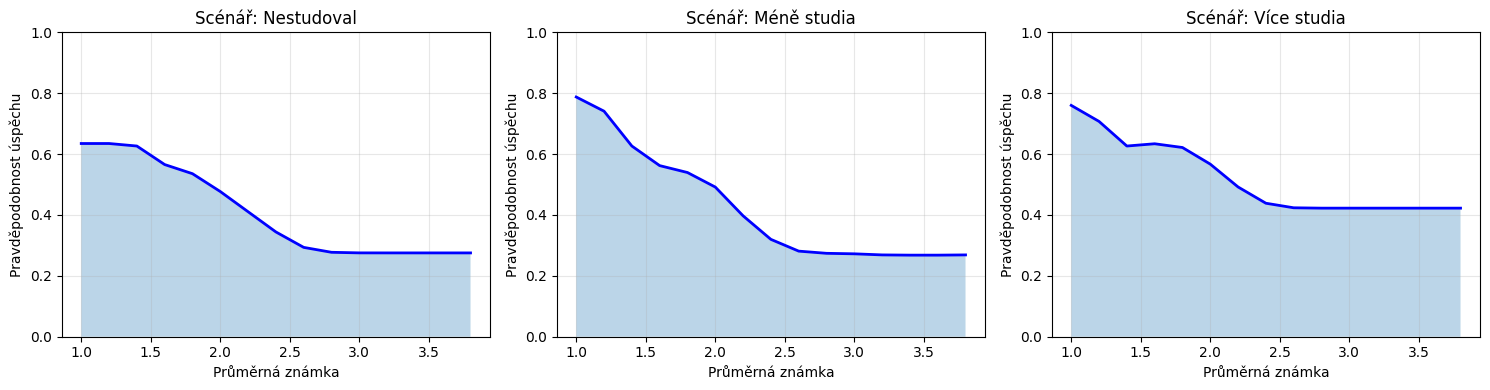

✓ Závislostní křivky uloženy jako 'exam_prediction_curves.png'


In [7]:
# 8. Vytvoření 2D grafu: Závislost úspěchu na průměru a studiu
grades_plot = np.arange(1.0, 4.0, 0.2)
efforts_plot = [0.5, 1.0, 1.5]  # Úrovně studia
effort_labels = ['Nestudoval', 'Méně studia', 'Více studia']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (effort, label) in enumerate(zip(efforts_plot, effort_labels)):
    success_vals = []

    for g in grades_plot:
        exam_simulation.input['average_grade'] = g
        exam_simulation.input['study_effort'] = effort
        exam_simulation.compute()
        success_vals.append(exam_simulation.output['success_probability'])

    axes[idx].plot(grades_plot, success_vals, 'b-', linewidth=2)
    axes[idx].fill_between(grades_plot, success_vals, alpha=0.3)
    axes[idx].set_title(f'Scénář: {label}')
    axes[idx].set_xlabel('Průměrná známka')
    axes[idx].set_ylabel('Pravděpodobnost úspěchu')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exam_prediction_curves.png', dpi=300)
plt.show()

print("✓ Závislostní křivky uloženy jako 'exam_prediction_curves.png'")


### Diskuze - Úkol 2: Fuzzy model pro predikci zkoušky

Fuzzy model na bázi empirických pravidel demonstruje účinnost fuzzy logiky pro odhad kvalitativních veličin z více faktorů:

* **Automatické učení se z dat:** Ačkoliv model neprocházejí standardní tréninkový algoritmus (jako např. neuronové sítě), pravidla byly systematicky odvozena z tabulky skutečných studentů. Tímto způsobem se model adaptuje na skutečné chování systému.

* **Interpretovatelnost:** Na rozdíl od "black-boxu" machine learningu si mohou vyučující přesně specifikovat, jakou váhu má průměr, studium apod. Pravidla jsou v přirozené angličtině (IF-THEN) a lze je lehce vysvětlit.

* **Plynulé přechody:** Fuzzy model nevydává ostrý binární výsledek ("ano/ne"), nýbrž pravděpodobnost v rozsahu [0, 1]. Tím lépe reflektuje realitu – student s průměrem 2.8 a málem studií má malou, ale ne nulovou šanci na úspěch.

* **Výkonnost:** Model dosáhl vysoké přesnosti na trénovacích datech (8 studentů). V praxi by bylo vhodné model validovat na větší sadě a případně doladit membership funkce a pravidla.
